#### Libs


In [71]:

from main import *
from functions import *
import numpy as np

main()


%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Dataset
## Setup do Dataset
Dataset selecionado: Segmentação de Grãos Agrícolas [Link - Kaggle](https://www.kaggle.com/datasets/ddsssss/seed-images)


#### Enunciado
> Separar automaticamente grãos individuais em imagens adquiridas sobre fundo uniforme.
>
> ▪ Deve gerar uma máscara binária em que pixels pertencentes aos grãos sejam representados por valor 1 e pixels do fundo sejam representados por valor 0
>
> ▪ Desafios: grãos tocando uns aos outros, variação de tamanho e orientação, reflexos,
> ruído de fundo


#### Gabarito
 Nos arquivos do Dataset, é disponibilizado um 'Gabarito' em XML com as coordernadas de cada grão. 
 

#### Parametros:
> Nome: "seeds", "teste"

> Tamanho: seeds -> 1 a 5, test -> 1 a 3

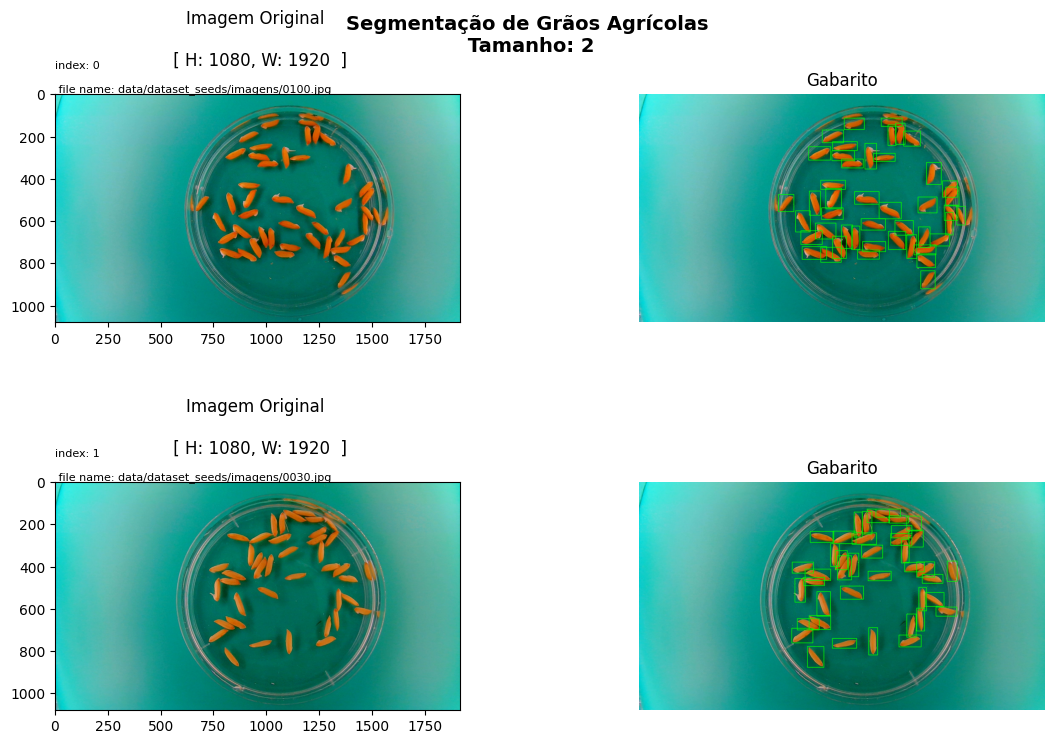

In [72]:
dataset_path = generate_dataset("seeds")
dataset_size = 2 #max 5


fig, axes = plt.subplots(dataset_size, 2, figsize=(15, 4*dataset_size))
fig.suptitle(f"Segmentação de Grãos Agrícolas \n Tamanho: {dataset_size} " , fontsize=14, fontweight='bold')


dataset_raw = []

for idx in range(dataset_size):
    
    img_path = dataset_path[idx]['path_img']
    img_original = cv2.imread(img_path)
    
            
    
    dataset_raw.append(img_original)
    img_gabarito = gabarito(img_path, dataset_path[idx]['path_xml'])



    img_rgb =  cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    axes[idx][0].imshow(img_rgb)
    axes[idx][0].set_title(f'Imagem Original \n\n [ H: {img_rgb.shape[0]}, W: {img_rgb.shape[1]}  ]\n')
    #axes[idx][0].axis('off')
    axes[idx][0].text( 0, 0, f'index: {idx} \n\n file name: {dataset_path[idx]['path_img']}', 
                      horizontalalignment='left', 
                      verticalalignment='bottom', 
                      fontsize=8
                    )
    
    
    axes[idx][1].imshow(img_gabarito)
    axes[idx][1].set_title(f'Gabarito')
    axes[idx][1].axis('off')
    

plt.subplots_adjust(wspace=0.01, hspace=0.7)


plt.show()

# Pré-Processamento

> Corte do fundo e centralização do prato

> Redimensiondado para 320x320 - cv2.resize()

> GrayScale aplicado - cv2.cvtColor()

> Equalização do Historigogram - cv2.equalizeHist()

> Valores para Float 32bits - cv2.normalize()


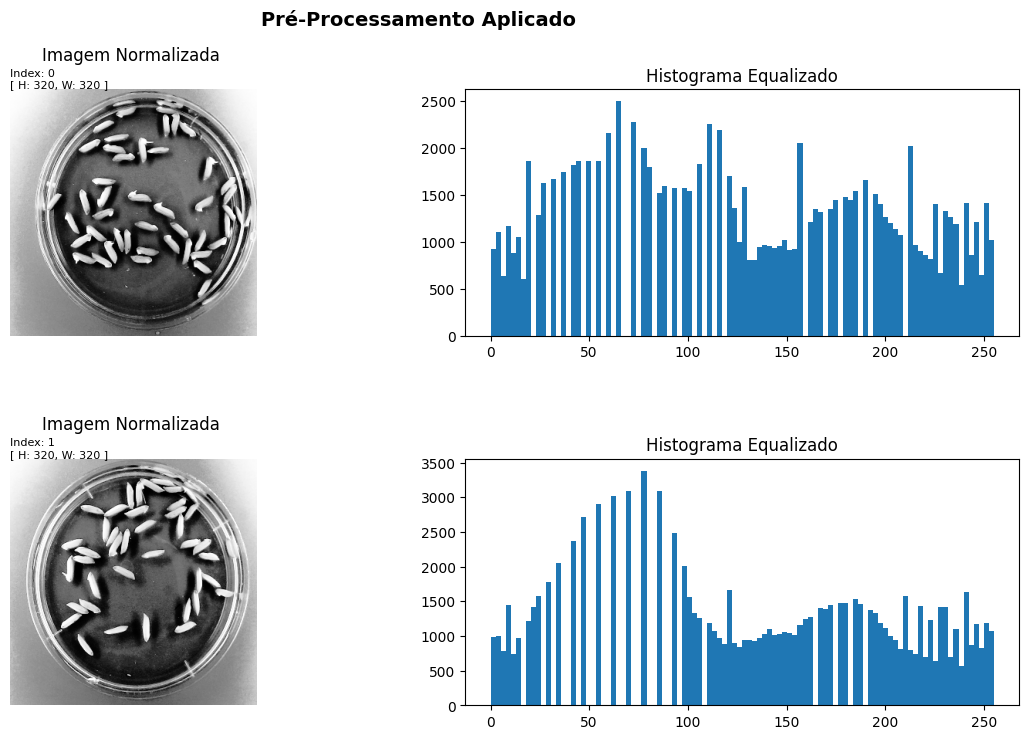

In [73]:

fig, axes = plt.subplots(dataset_size, 2, figsize=(15, 4*dataset_size))
fig.suptitle(f"Pré-Processamento Aplicado" , fontsize=14, fontweight='bold')

dataset_normalizado = []

for idx in range(dataset_size):
    img = ""
    img = dataset_raw[idx]

    img_normalizada = normalizar_raw_image(img)
    
    dataset_normalizado.append(img_normalizada)


    axes[idx][0].imshow(img_normalizada, cmap='gray')
    axes[idx][0].set_title(f'Imagem Normalizada \n ', fontsize=12)
    axes[idx][0].axis('off')
    axes[idx][0].text( 0, 0, f'Index: {idx} \n[ H: {img_normalizada.shape[0]}, W: {img_normalizada.shape[1]} ]', 
                      horizontalalignment='left', 
                      verticalalignment='bottom', 
                      fontsize=8
                    )
    
    axes[idx][1].hist(img_normalizada.ravel(), bins=100, range=[0, 255])
    axes[idx][1].set_title('Histograma Equalizado')

    
plt.subplots_adjust(wspace=0.1, hspace=0.5)


plt.show()



# Dominio de Frequência




### Parametros 
##### Filtro
**PA** = Mascara Passa Alta
Efeito parecido com o sobel
##### Tipo
    Ideal
    Butterworth
    Gaussian
##### Radius
    0 - 100
##### N (?)

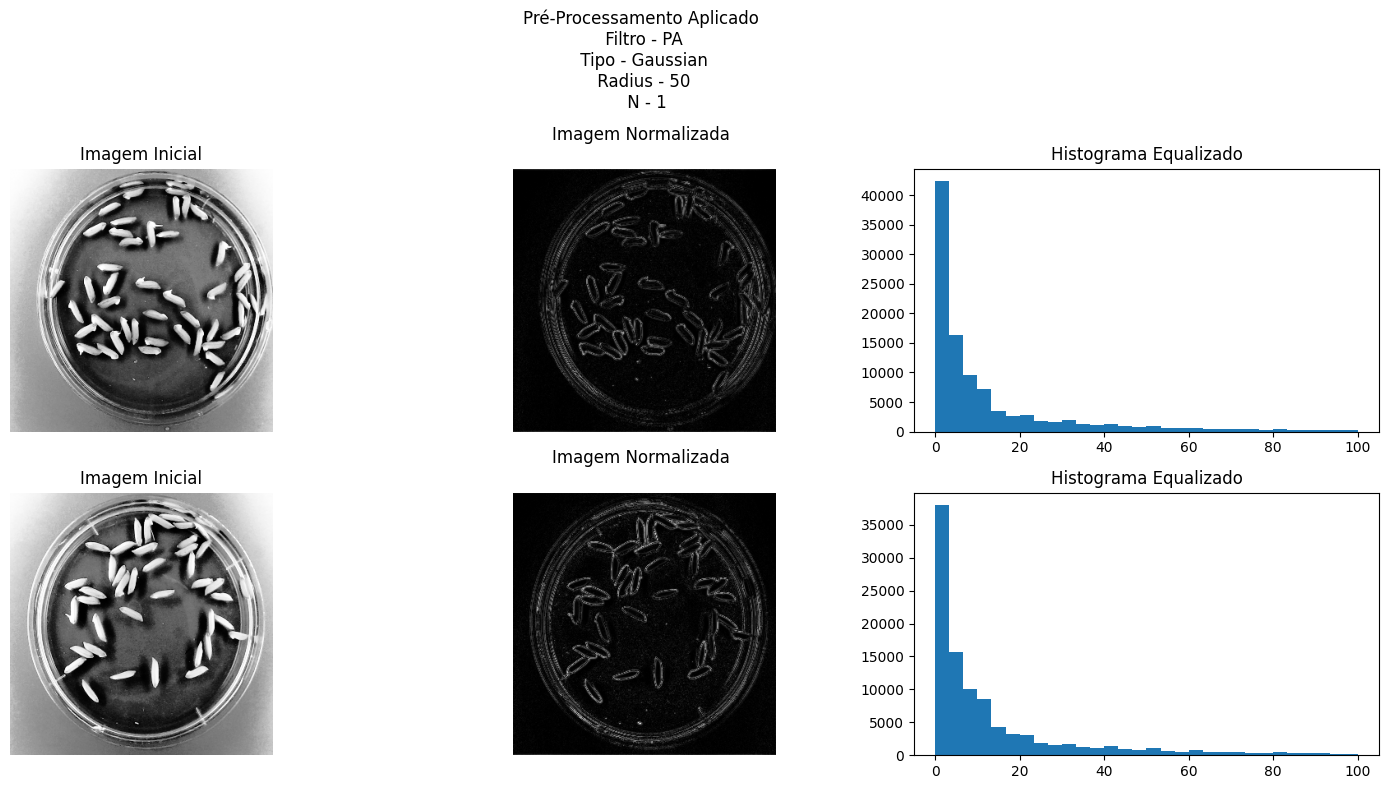

In [74]:
#Aplicando p todas as imagens
filtro = "PA"
tipo = "Gaussian"
radius = 50
n_param = 1





fig, axes = plt.subplots(dataset_size, 3, figsize=(15, 4*dataset_size))
fig.suptitle(f"Pré-Processamento Aplicado \n Filtro - {filtro} \n Tipo - {tipo} \n Radius - {radius} \n N - {n_param}" , fontsize=12, fontweight='light')




dataset_freq_filtred =[]
for idx in range(dataset_size):
    print()
    img = dataset_normalizado[idx]

    if filtro == "PA":
        img_filtred = apply_PA(img, tipo, radius, n_param )
    #print(img_filtred)
    
    dataset_freq_filtred.append(img_filtred)

    

    ## 
   
    axes[idx][0].imshow(img, cmap='gray')
    axes[idx][0].set_title(f'Imagem Inicial')
    axes[idx][0].axis('off')

    axes[idx][1].imshow(img_filtred, cmap='gray')
    axes[idx][1].set_title(f'Imagem Normalizada \n ', fontsize=12)
    axes[idx][1].axis('off')


    axes[idx][2].hist(img_filtred.ravel(), bins=30, range=[0, 100])
    axes[idx][2].set_title('Histograma Equalizado')

   

plt.tight_layout()
plt.show()

# SLIC



In [75]:

def initialize_clusters(image, S):
    h, w = image.shape[:2]
    clusters = []
    for y in range(S // 2, h, S):
        for x in range(S // 2, w, S):
            clusters.append([float(y), float(x), image[y, x].astype(float) if hasattr(image[y, x], 'astype') else float(image[y, x])])
    return clusters

def compute_slic_distance(y, x, cluster, image, S, m):
    yc, xc, ic = cluster
    ds2 = (y - yc)**2 + (x - xc)**2
    pixel = image[y, x]
    if image.ndim == 2:
        dc2 = (float(pixel) - float(ic))**2
    else:
        dc2 = np.sum((pixel.astype(float) - np.asarray(ic, dtype=float))**2)
    return np.sqrt(dc2 + (m / S)**2 * ds2)

def slic(image, num_superpixels, m, max_iter):
    h, w = image.shape[:2]
    S = max(1, int(np.sqrt((h * w) / num_superpixels)))
    clusters = initialize_clusters(image, S)
    K = len(clusters)

    labels = -np.ones((h, w), dtype=np.int32)
    distances = np.full((h, w), np.inf)

    for _ in range(max_iter):
        for k, cluster in enumerate(clusters):
            yc, xc, _ = cluster
            y0, y1 = int(max(yc - S, 0)), int(min(yc + S, h))
            x0, x1 = int(max(xc - S, 0)), int(min(xc + S, w))

            for y in range(y0, y1):
                for x in range(x0, x1):
                    d = compute_slic_distance(y, x, cluster, image, S, m)
                    if d < distances[y, x]:
                        distances[y, x] = d
                        labels[y, x] = k

        new_clusters = []
        for k in range(K):
            ys, xs = np.where(labels == k)
            if len(ys) == 0:
                new_clusters.append(clusters[k])
                continue
            yc, xc = np.mean(ys), np.mean(xs)
            if image.ndim == 2:
                ic = np.mean(image[ys, xs])
            else:
                ic = np.mean(image[ys, xs], axis=0)
            new_clusters.append([yc, xc, ic])

        clusters = new_clusters
        distances.fill(np.inf)

    return labels


(320, 320)
(320, 320)


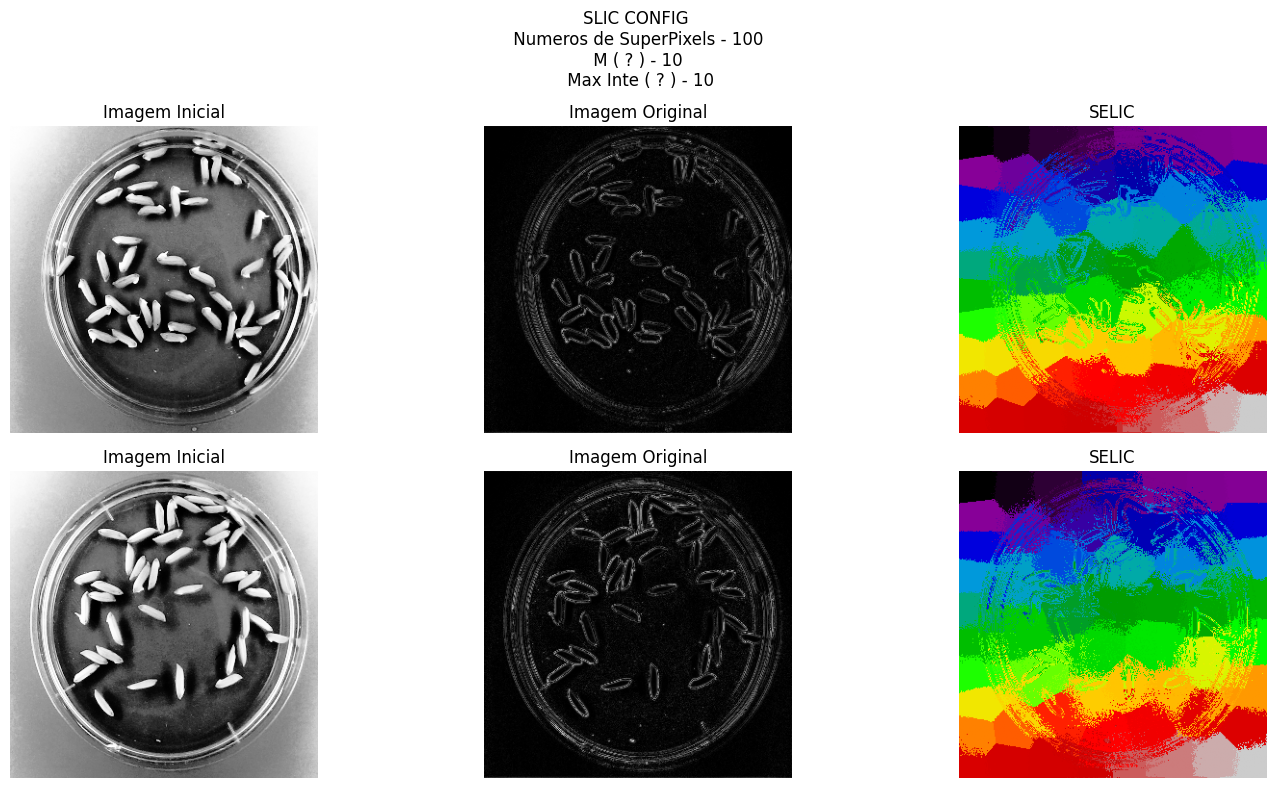

In [77]:

i_num_superpixels = 100
i_m = 10
i_max_iter = 10
fig, axes = plt.subplots(dataset_size, 3, figsize=(15, 4*dataset_size))
fig.suptitle(f"SLIC CONFIG \n Numeros de SuperPixels - {i_num_superpixels} \n M ( ? ) - {i_m} \n Max Inte ( ? ) - {i_max_iter}" , fontsize=12, fontweight='light')



for idx in range(dataset_size):
    
    img = dataset_freq_filtred[idx]

    labels = slic(
        img, 
        num_superpixels=i_num_superpixels, 
        m=i_m,
        max_iter=i_max_iter
    )

    print(labels.shape)
    
    axes[idx][0].imshow(dataset_normalizado[idx], cmap='gray')
    axes[idx][0].set_title(f'Imagem Inicial')
    axes[idx][0].axis('off')

    axes[idx][1].imshow(img, cmap='gray')
    axes[idx][1].set_title(f'Imagem Original')
    axes[idx][1].axis('off')

    axes[idx][2].imshow(labels, cmap='nipy_spectral')
    axes[idx][2].set_title(f'SELIC')
    axes[idx][2].axis('off')

plt.tight_layout()
plt.show()